In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
class multipleLinearRegression:
    
    def __init__(self):
        self.W0 = None
        self.W1 = None
        self.W2 = None
        self.SSE = float('inf')
        self.MSE = None
    
    def fit(self,X1,X2,y,LR=0.01,epochs=1000, tolerance=1e-6):
        self.n=len(X1)
        self.X1 =np.array(X1)
        self.X2 = np.array(X2)
        self.y = np.array(y)
        self.W0 =0
        self.W1 =0
        self.W2 =0
        
        for _ in range(epochs):
            y_hat = self.W0 + self.W1*self.X1 + self.W2*self.X2
            error = self.y - y_hat
            dw0 = (-1 / self.n )* np.sum(error)
            dw1 = (-1 / self.n) * np.sum(error * self.X1)
            dw2 = (-1 / self.n) * np.sum(error * self.X2)
            
            self.W0 -= LR * dw0
            self.W1 -= LR * dw1
            self.W2 -= LR * dw2
            
            new_SSE = np.sum((y - (self.W0 + self.W1 * X1 + self.W2 *self.X2))**2)
            
            if abs(new_SSE - self.SSE )< tolerance:
                self.SSE = new_SSE
                break
            self.SSE = new_SSE
            
            self.MSE = self.SSE / (2*self.n)

    def predict (self, X1, X2):
        if self.W1 is None or self.W0 is None or self.W2 is None:
            raise ValueError('the model has not been fitted yet. ')
        X1 = np.array(X1)
        X2 = np.array(X2)
        return self.W0 + self.W1 * X1 + self.W2 * X2
    
    def plot(self,X1,X2,Y):
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(X1, X2, Y, color='blue', label='Data')
        
        X1_grid, X2_grid = np.meshgrid(np.linspace(min(X1),max(X1),20),
                                        np.linspace(min(X2),max(X2),20))
        Y_pred = self.W0 + self.W1*X1_grid + self.W2*X2_grid
        ax.plot_surface(X1_grid, X2_grid, Y_pred, color='red', alpha=0.5)
        
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_zlabel('Y')
        plt.legend()
        ax.view_init(elev=10, azim=120)
        plt.show()

In [3]:
df =pd.read_csv('employee_income.csv')
df.head()

,age,experience,income
0,50,5,45118
1,36,9,41691
2,29,3,35994
3,42,5,41614
4,40,12,51474


In [4]:
X1 =df['age']
X2 =df['experience']
y = df['income']


In [5]:
model = multipleLinearRegression()
model.fit(X1,X2,y,0.001,10)

In [6]:
print("Evaluation of the model")
print("------------------------")
print(f'Line of best fit is: y = {round(model.W0,2)} + {round(model.W1,2)} X1 + {round(model.W2,2)} X2')
print(f'Mean squared error is: {round(model.MSE,3)}')

Evaluation of the model
------------------------
Line of best fit is: y = 44.39 + 945.33 X1 + 604.66 X2
Mean squared error is: 37984861.956


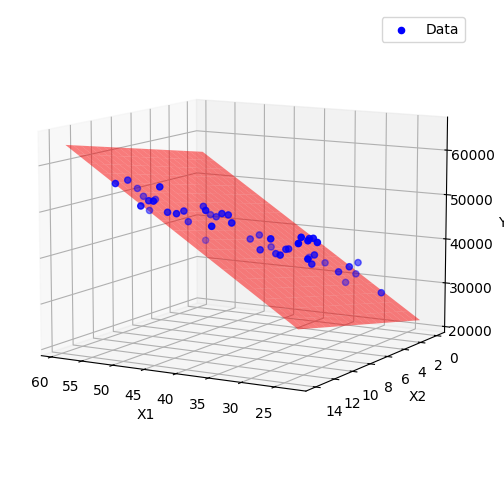

In [7]:
model.plot(X1,X2,y)

## Change number of iterations 

In [8]:
model = multipleLinearRegression()
model.fit(X1,X2,y,0.001,300000)

In [17]:
print("Evaluation of the model")
print("------------------------")
print(f'Line of best fit is: y = {round(model.W0,2)} + {round(model.W1,2)} X1 + {round(model.W2,2)} X2')
print(f'Mean squared error is: {round(model.MSE,3)}')


Evaluation of the model
------------------------
Line of best fit is: y = 19460.93 + 321.04 X1 + 1506.68 X2
Mean squared error is: 1704910.301


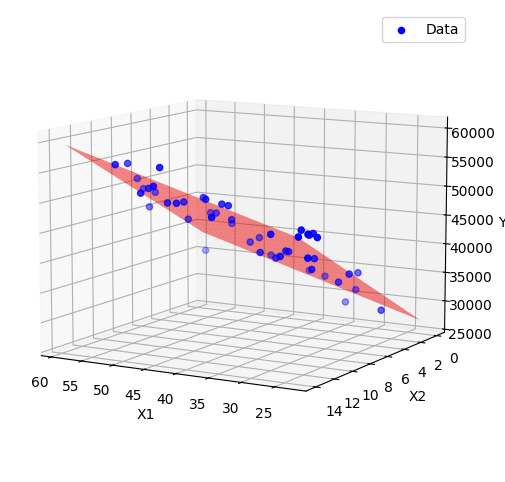

In [10]:
model.plot(X1,X2,y)

In [29]:
for i in range(0,20):
    print(f'Acual value: {y[i]}, predicted value: {int(model.W0 + model.W1 * X1[i] + model.W2 *X2[i])}, error: {y[i]-int(model.W0 + model.W1 * X1[i] + model.W2 *X2[i])}')

Acual value: 45118, predicted value: 43046, error: 2072
Acual value: 41691, predicted value: 44578, error: -2887
Acual value: 35994, predicted value: 33291, error: 2703
Acual value: 41614, predicted value: 40478, error: 1136
Acual value: 51474, predicted value: 50382, error: 1092
Acual value: 57092, predicted value: 54680, error: 2412
Acual value: 31661, predicted value: 31241, error: 420
Acual value: 42378, predicted value: 43294, error: -916
Acual value: 50099, predicted value: 50481, error: -382
Acual value: 35800, predicted value: 39267, error: -3467
Acual value: 49959, predicted value: 47468, error: 2491
Acual value: 48575, predicted value: 46752, error: 1823
Acual value: 37504, predicted value: 37785, error: -281
Acual value: 47998, predicted value: 46431, error: 1567
Acual value: 53954, predicted value: 55001, error: -1047
Acual value: 56945, predicted value: 56927, error: 18
Acual value: 51047, predicted value: 48949, error: 2098
Acual value: 44204, predicted value: 46431, erro

# Multiple Linear Regression Results

### 📊 Error Improvement
- The model’s error has **decreased noticeably** compared to earlier runs.  
- The **average prediction gap** between actual and predicted values is now **1305.72**.  

### 💡 Why This Is Good
- Income values in the dataset are **large**, typically ranging between **30,000 and 50,000**.  
- An error of ~1300 is **small relative to the scale** of these values.  
- This means the model is capturing the relationship between age, experience, and income **effectively**.  

### ✅ Conclusion
The regression plane provides predictions with a relatively low error margin.  
Given the magnitude of the income values, the model’s performance is **strong and reliable**.
